# Plotting System for Jisugwimundo, Magic Hexagons, and Magic Hexagrams  

This plotting system is designed for magic hexagons whose six sides
are not necessarily of equal length.

In fact, Jisugquimundo can be regarded as a type of magic hexagon
composed of triangular cells, in which the six sides may have
arbitrary lengths.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from dataclasses import dataclass

SQRT3 = np.sqrt(3)
H = SQRT3 / 2

# ------------------------------------------------------------
# Six boundary directions
#
# sides = (a,b,c,d,e,f)
#
# a = top horizontal side, followed clockwise.
#
# A zero-length side is allowed.  It represents a degenerate
# side: no movement occurs, but the boundary direction advances.
# ------------------------------------------------------------

DIRECTIONS = np.array([
    [ 1.0,  0.0],
    [ 0.5, -H],
    [-0.5, -H],
    [-1.0,  0.0],
    [-0.5,  H],
    [ 0.5,  H],
])


# ============================================================
# Result object for inverse analysis
# ============================================================

@dataclass
class ShapeAnalysis:
    status: str
    row_lengths: tuple
    n_rows: int
    n_cells: int
    candidates: tuple
    reason: str = ""

    @property
    def is_valid(self):
        return self.status in ("unique", "ambiguous")

    @property
    def is_unique(self):
        return self.status == "unique"

    @property
    def sides(self):
        if self.is_unique:
            return self.candidates[0]
        return None


# ============================================================
# 1. Boundary
# ============================================================

def boundary_vertices(sides):
    """
    Return boundary vertices for sides=(a,b,c,d,e,f).

    Convention:
        - a is the top horizontal side.
        - boundary is followed clockwise.
        - zero-length sides are allowed.
    """

    if len(sides) != 6:
        raise ValueError("sides must contain exactly six integers.")

    sides = tuple(int(x) for x in sides)

    if any(x < 0 for x in sides):
        raise ValueError("side lengths must be nonnegative.")

    p = np.array([0.0, 0.0])
    vertices = [p.copy()]

    for length, direction in zip(sides, DIRECTIONS):
        p = p + length * direction
        vertices.append(p.copy())

    return np.array(vertices)


def is_closed(sides, tol=1e-9):
    """Check whether the six sides form a closed boundary."""
    v = boundary_vertices(sides)
    return np.linalg.norm(v[-1] - v[0]) < tol


# ============================================================
# 2. Enumerate unit triangular cells
# ============================================================

def triangular_cells(sides):
    """
    Enumerate all unit triangular cells inside the boundary.

    Each returned item contains:
        orientation : 'up' or 'down'
        vertices    : 3x2 array
        center      : centroid
        strip       : horizontal row index
    """

    if not is_closed(sides):
        raise ValueError(
            f"sides={tuple(sides)} does not form a closed region."
        )

    boundary = boundary_vertices(sides)

    # Repeated vertices caused by zero sides are harmless.
    polygon = Path(boundary[:-1])

    xmin = boundary[:, 0].min()
    xmax = boundary[:, 0].max()

    ymin = boundary[:, 1].min()
    ymax = boundary[:, 1].max()

    kmin = int(np.floor(ymin / H)) - 2
    kmax = int(np.ceil(ymax / H)) + 2

    # Safe horizontal search range.
    imin = int(np.floor(xmin)) - max(sides) - 3
    imax = int(np.ceil(xmax)) + max(sides) + 3

    cells = []

    for k in range(kmin, kmax + 1):

        # Lattice points on horizontal level k are
        #
        # x = i + k/2
        # y = k H

        for i in range(imin, imax + 1):

            x = i + k / 2
            y = k * H

            # upward triangle
            up = np.array([
                [x,       y],
                [x + 1.0, y],
                [x + 0.5, y + H],
            ])

            # downward triangle
            down = np.array([
                [x,       y],
                [x + 1.0, y],
                [x + 0.5, y - H],
            ])

            for orientation, tri in (
                ("up", up),
                ("down", down),
            ):

                center = tri.mean(axis=0)

                # For these lattice polygons the centroid test is
                # sufficient to determine the unit cells belonging
                # to the region.
                if polygon.contains_point(center, radius=1e-9):

                    levels = tri[:, 1] / H
                    strip = int(round(levels.min()))

                    cells.append({
                        "orientation": orientation,
                        "vertices": tri,
                        "center": center,
                        "strip": strip,
                    })

    return cells


# ============================================================
# 3. Convert sides -> rows
# ============================================================

def cells_by_row(sides):
    """
    Return unit triangular cells grouped into horizontal rows,
    from top to bottom.
    """

    cells = triangular_cells(sides)

    rows = {}

    for cell in cells:
        rows.setdefault(cell["strip"], []).append(cell)

    # larger strip = visually higher
    ordered = []

    for strip in sorted(rows, reverse=True):

        row = rows[strip]

        # left-to-right
        row.sort(key=lambda c: c["center"][0])

        ordered.append(row)

    return ordered


def row_lengths_from_sides(sides):
    """
    Example:
        (0,3,0,3,0,3) -> (1,3,5)
        (1,3,3,1,3,3) -> (3,5,7,7,5,3)
        (2,2,2,2,2,2) -> (5,7,7,5)
    """

    return tuple(len(row) for row in cells_by_row(sides))


def cell_count_from_sides(sides):
    return sum(row_lengths_from_sides(sides))


# ============================================================
# 4. Some Jigusugwimundo families
# ============================================================

def jigusugwimundo_sides(n, kind="rhombic"):
    """
    Convert a named family and order n to sides=(a,b,c,d,e,f).

    n is measured in unit-triangle edges.
    """

    if not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError("n must be a positive integer.")

    if kind == "triangle":

        # ordinary triangular array
        return (0, n, 0, n, 0, n)

    elif kind == "rhombic":

        # conventional order-n Jigusugwimundo form
        return (1, n, n, 1, n, n)

    elif kind == "regular_hexagon":

        return (n, n, n, n, n, n)

    else:
        raise ValueError(
            f"Unknown kind {kind!r}. "
            "Use 'triangle', 'rhombic', or 'regular_hexagon'."
        )


# ============================================================
# 5. Inverse problem: data -> possible sides
# ============================================================

def analyze_jigusugwimundo_shape(data, max_side=None):
    """
    Infer possible (a,b,c,d,e,f) from row lengths alone.

    Returns
    -------
    ShapeAnalysis

    status:
        'unique'
            exactly one six-side representation was found

        'ambiguous'
            two or more geometrically different representations
            have exactly the same row lengths

        'invalid'
            no representation was found

    Important
    ---------
    Row lengths do NOT always determine the geometry uniquely.
    Odd/even transitions are one important source of ambiguity.
    """

    if len(data) == 0:
        return ShapeAnalysis(
            status="invalid",
            row_lengths=(),
            n_rows=0,
            n_cells=0,
            candidates=(),
            reason="data contains no rows.",
        )

    row_lengths = tuple(len(row) for row in data)

    if any(L <= 0 for L in row_lengths):
        return ShapeAnalysis(
            status="invalid",
            row_lengths=row_lengths,
            n_rows=len(row_lengths),
            n_cells=sum(row_lengths),
            candidates=(),
            reason="Every row must contain at least one triangle.",
        )

    n_rows = len(row_lengths)
    n_cells = sum(row_lengths)

    # A deliberately conservative automatic bound.
    #
    # The user can increase this for unusual large shapes.
    if max_side is None:
        max_side = max(max(row_lengths), n_rows) + 1

    candidates = []

    # --------------------------------------------------------
    # Closure conditions reduce the six-dimensional search.
    #
    # With our direction convention:
    #
    #     a + b = d + e
    #     b + c = e + f
    #
    # so once a,b,c,d are selected:
    #
    #     e = a+b-d
    #     f = b+c-e
    #
    # --------------------------------------------------------

    for a in range(max_side + 1):
        for b in range(max_side + 1):
            for c in range(max_side + 1):
                for d in range(max_side + 1):

                    e = a + b - d

                    if e < 0 or e > max_side:
                        continue

                    f = b + c - e

                    if f < 0 or f > max_side:
                        continue

                    sides = (a, b, c, d, e, f)

                    if sum(sides) == 0:
                        continue

                    try:
                        generated = row_lengths_from_sides(sides)
                    except ValueError:
                        continue

                    # Crucial step:
                    # reconstruct forward and compare exactly.
                    if generated == row_lengths:
                        candidates.append(sides)

    # Remove exact duplicates
    candidates = tuple(sorted(set(candidates)))

    if len(candidates) == 0:

        return ShapeAnalysis(
            status="invalid",
            row_lengths=row_lengths,
            n_rows=n_rows,
            n_cells=n_cells,
            candidates=(),
            reason=(
                "No six-side triangular-grid region reproduces "
                "these row lengths within the search bound."
            ),
        )

    elif len(candidates) == 1:

        return ShapeAnalysis(
            status="unique",
            row_lengths=row_lengths,
            n_rows=n_rows,
            n_cells=n_cells,
            candidates=candidates,
            reason="The six-side representation is unique.",
        )

    else:

        return ShapeAnalysis(
            status="ambiguous",
            row_lengths=row_lengths,
            n_rows=n_rows,
            n_cells=n_cells,
            candidates=candidates,
            reason=(
                "The row lengths are geometrically valid, but "
                "do not uniquely determine the six-side boundary."
            ),
        )


# ============================================================
# 6. Validate data against known sides
# ============================================================

def validate_data_shape(data, sides):
    """
    Check whether data has exactly the row structure required
    by sides=(a,b,c,d,e,f).
    """

    actual = tuple(len(row) for row in data)
    expected = row_lengths_from_sides(sides)

    if actual != expected:
        raise ValueError(
            "Invalid data shape.\n"
            f"Expected row lengths: {expected}\n"
            f"Actual row lengths:   {actual}"
        )

    return True


# ============================================================
# 7. Plot
# ============================================================

def plot_jigusugwimundo(
    data,
    sides,
    title=None,
    fontsize=13,
    figsize=(9, 9),
):
    """
    Plot data on the triangular-grid region defined by sides.
    """

    validate_data_shape(data, sides)

    rows = cells_by_row(sides)

    fig, ax = plt.subplots(figsize=figsize)

    all_x = []
    all_y = []

    for values, cells in zip(data, rows):

        for value, cell in zip(values, cells):

            tri = cell["vertices"]
            center = cell["center"]

            polygon = plt.Polygon(
                tri,
                closed=True,
                fill=False,
                edgecolor="black",
                linewidth=1,
            )

            ax.add_patch(polygon)

            ax.text(
                center[0],
                center[1],
                str(value),
                ha="center",
                va="center",
                fontsize=fontsize,
                color="black",
            )

            all_x.extend(tri[:, 0])
            all_y.extend(tri[:, 1])

    ax.set_aspect("equal")
    ax.axis("off")

    margin = 0.2

    ax.set_xlim(
        min(all_x) - margin,
        max(all_x) + margin
    )

    ax.set_ylim(
        min(all_y) - margin,
        max(all_y) + margin
    )

    if title is not None:
        ax.set_title(
            str(title),
            fontsize=fontsize + 2,
            color="black",
            pad=8,
        )

    plt.tight_layout(pad=0.2)
    plt.show()

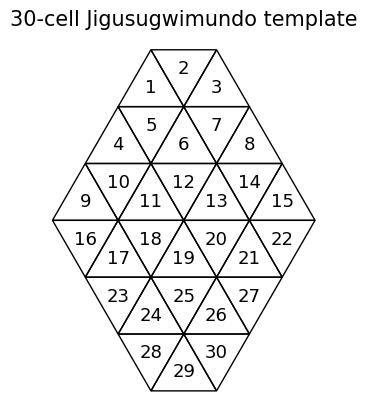

In [4]:
data30 = [
    [ 1,  2,  3],
    [ 4,  5,  6,  7,  8],
    [ 9, 10, 11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20, 21, 22],
    [23, 24, 25, 26, 27],
    [28, 29, 30],
]

plot_jigusugwimundo(
    data30,
    sides=(1, 3, 3, 1, 3, 3),
    title="30-cell Jigusugwimundo template",
    fontsize=13,
    figsize=(4, 4),
)

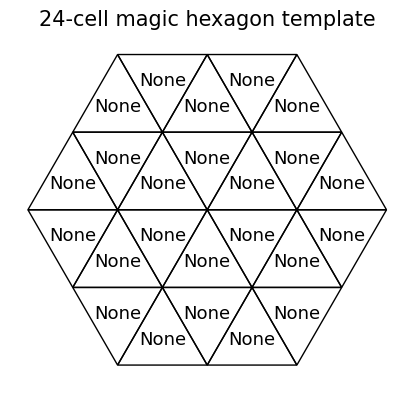

In [5]:
def empty_hexagon_data(sides):
    """
    Create an empty data array matching the triangular-cell
    row structure of sides=(a,b,c,d,e,f).

    Empty cells are represented by None.
    """

    # 기존 함수가 있다면 이것을 그대로 이용
    lengths = row_lengths_from_sides(sides)

    return [
        [None] * length
        for length in lengths
    ]


def print_empty_hexagon_data(sides, variable_name="data"):
    """
    Print copy-pasteable Python code for an empty array
    matching sides=(a,b,c,d,e,f).
    """

    data = empty_hexagon_data(sides)

    print(f"{variable_name} = [")

    for row in data:
        contents = ", ".join("None" for _ in row)
        print(f"    [{contents}],")

    print("]")
    
    
plot_jigusugwimundo(
    empty_hexagon_data((2, 2, 2, 2, 2, 2)),
    sides=(2, 2, 2, 2, 2, 2),
    title="24-cell magic hexagon template",
    fontsize=13,
    figsize=(4, 4),
)

# plot hexagram

In [7]:
import numpy as np
import matplotlib.pyplot as plt


SQRT3 = np.sqrt(3)
H = SQRT3 / 2


# ============================================================
# Basic triangular-lattice cells
# ============================================================

def _triangle_key(vertices):
    """
    Make a hashable key for a unit triangle.
    """
    pts = [
        (round(float(x), 10), round(float(y), 10))
        for x, y in vertices
    ]
    return tuple(sorted(pts))


def _make_cell(vertices):
    vertices = np.asarray(vertices, dtype=float)
    center = vertices.mean(axis=0)

    return {
        "vertices": vertices,
        "center": center,
    }


def _equilateral_triangle_cells(n, orientation="up",
                                center=(0.0, 0.0)):
    """
    Generate all unit triangular cells inside an equilateral
    triangle of side length n.

    orientation:
        "up"   : upward-pointing large triangle
        "down" : downward-pointing large triangle
    """

    if not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError("n must be a positive integer.")

    cells = {}

    # --------------------------------------------------------
    # First construct an upward triangle with vertices
    #
    #       (0, nH)
    #       /      \
    #    (0,0)----(n,0)
    #
    # Then translate its centroid to the requested center.
    # --------------------------------------------------------

    for level in range(n):

        # At this horizontal strip there are
        # 2*(n-level)-1 unit triangles.

        width = n - level

        x_start = level / 2
        y = level * H

        for j in range(2 * width - 1):

            x = x_start + j / 2

            if j % 2 == 0:

                tri = np.array([
                    [x,       y],
                    [x + 1.0, y],
                    [x + 0.5, y + H],
                ])

            else:

                tri = np.array([
                    [x,       y + H],
                    [x + 1.0, y + H],
                    [x + 0.5, y],
                ])

            cells[_triangle_key(tri)] = _make_cell(tri)

    # centroid of the large upward triangle
    original_center = np.array([
        n / 2,
        n * H / 3
    ])

    target_center = np.asarray(center, dtype=float)

    # --------------------------------------------------------
    # Reflect for downward triangle
    # --------------------------------------------------------

    result = {}

    for cell in cells.values():

        tri = cell["vertices"].copy()

        tri -= original_center

        if orientation == "down":
            tri[:, 1] *= -1

        elif orientation != "up":
            raise ValueError(
                "orientation must be 'up' or 'down'."
            )

        tri += target_center

        result[_triangle_key(tri)] = _make_cell(tri)

    return result


# ============================================================
# Hexagram
# ============================================================
def hexagram_cells(n, cut=0):
    """
    Order-n hexagram.

    The hexagram is the union of two equilateral triangles
    of side length 3*n.

    cut=a removes an equilateral triangular tip of side a
    from each of the six points.

    Therefore:

        number of cells = 12*n^2 - 6*cut^2
    """

    if not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError("n must be a positive integer.")

    if not isinstance(cut, (int, np.integer)) or cut < 0:
        raise ValueError("cut must be a nonnegative integer.")

    if cut > n:
        raise ValueError(
            f"cut must satisfy 0 <= cut <= n; "
            f"got n={n}, cut={cut}."
        )

    L = 3 * n

    # --------------------------------------------------
    # Make the two large triangles separately.
    # --------------------------------------------------

    up = _equilateral_triangle_cells(
        L,
        orientation="up",
        center=(0.0, 0.0)
    )

    down = _equilateral_triangle_cells(
        L,
        orientation="down",
        center=(0.0, 0.0)
    )

    # No truncation
    if cut == 0:
        star = dict(up)
        star.update(down)

        result = list(star.values())

        assert len(result) == 12 * n * n

        return result

    # --------------------------------------------------
    # Generate the six triangular pieces to remove.
    #
    # This time they are ACTUAL equilateral triangles
    # of side length `cut`, rather than projection bands.
    # --------------------------------------------------

    big_height = L * H

    # Vertices of the upward large triangle,
    # after centering at (0, 0).
    #
    # top
    # bottom-left
    # bottom-right

    up_vertices = np.array([
        [0.0,          2 * big_height / 3],
        [-L / 2,      -big_height / 3],
        [ L / 2,      -big_height / 3],
    ])

    # Downward triangle is its vertical reflection.
    down_vertices = up_vertices.copy()
    down_vertices[:, 1] *= -1

    # --------------------------------------------------
    # Helper:
    # select the cut^2 cells closest to one vertex,
    # but only from the triangle owning that vertex.
    #
    # On a triangular lattice, a side-a corner contains
    # exactly a^2 unit triangular cells.
    # --------------------------------------------------

    def corner_cells(cells_dict, vertex, count):

        items = list(cells_dict.items())

        distances = []

        for key, cell in items:

            center = cell["center"]

            d2 = np.sum(
                (center - vertex) ** 2
            )

            distances.append(
                (d2, key)
            )

        distances.sort(
            key=lambda x: x[0]
        )

        return {
            key
            for _, key in distances[:count]
        }

    remove = set()

    count_per_tip = cut * cut

    # Three tips belonging to upward triangle
    for vertex in up_vertices:

        remove |= corner_cells(
            up,
            vertex,
            count_per_tip
        )

    # Three tips belonging to downward triangle
    for vertex in down_vertices:

        remove |= corner_cells(
            down,
            vertex,
            count_per_tip
        )

    # --------------------------------------------------
    # Union of the two large triangles
    # --------------------------------------------------

    star = dict(up)
    star.update(down)

    result = [
        cell
        for key, cell in star.items()
        if key not in remove
    ]

    # --------------------------------------------------
    # Sanity check
    # --------------------------------------------------

    expected = (
        12 * n * n
        - 6 * cut * cut
    )

    if len(result) != expected:
        raise RuntimeError(
            "Internal hexagram geometry error.\n"
            f"n={n}, cut={cut}\n"
            f"Expected {expected} cells, "
            f"but generated {len(result)}."
        )

    return result

# ============================================================
# Group into rows
# ============================================================

def hexagram_rows(n, cut=0):
    """
    Return hexagram cells grouped into horizontal rows,
    top to bottom and left to right.
    """

    cells = hexagram_cells(n, cut)

    if not cells:
        return []

    # Group by y-coordinate of the cell center.
    #
    # Unit triangles have two centroid heights within each
    # horizontal strip, but for displaying alternating
    # triangular cells as one row we group them by strip.

    rows = {}

    for cell in cells:

        tri = cell["vertices"]

        y_min = tri[:, 1].min()

        strip = round(y_min / H)

        rows.setdefault(strip, []).append(cell)

    result = []

    for strip in sorted(rows, reverse=True):

        row = rows[strip]

        row.sort(
            key=lambda cell: cell["center"][0]
        )

        result.append(row)

    return result


def hexagram_row_lengths(n, cut=0):
    """
    Return number of triangular cells in each row.
    """
    return tuple(
        len(row)
        for row in hexagram_rows(n, cut)
    )


def hexagram_cell_count(n, cut=0):
    """
    Total number of triangular cells.
    """
    return sum(hexagram_row_lengths(n, cut))


# ============================================================
# Empty data
# ============================================================

def empty_hexagram_data(n, cut=0):
    """
    Create an empty data array matching the hexagram.
    """

    return [
        [None] * length
        for length in hexagram_row_lengths(n, cut)
    ]


def print_empty_hexagram_data(
    n,
    cut=0,
    variable_name="data"
):
    """
    Print copy-pasteable Python code.
    """

    lengths = hexagram_row_lengths(n, cut)

    print(f"{variable_name} = [")

    for length in lengths:

        contents = ", ".join(
            "None"
            for _ in range(length)
        )

        print(f"    [{contents}],")

    print("]")


# ============================================================
# Plot
# ============================================================

def plot_hexagram(
    data,
    n,
    cut=0,
    title=None,
    fontsize=13,
    figsize=(9, 9),
):
    """
    Plot data on an order-n hexagram.

    Parameters
    ----------
    data
        Values arranged from top row to bottom row.

    n
        Hexagram order.

    cut
        Equal truncation of all six tips.

    title
        Optional title.
    """

    rows = hexagram_rows(n, cut)

    expected = tuple(
        len(row)
        for row in rows
    )

    actual = tuple(
        len(row)
        for row in data
    )

    if actual != expected:

        raise ValueError(
            "Data does not match the hexagram.\n"
            f"n = {n}, cut = {cut}\n"
            f"Expected row lengths: {expected}\n"
            f"Actual row lengths:   {actual}"
        )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    all_x = []
    all_y = []

    for values, row in zip(data, rows):

        for value, cell in zip(values, row):

            tri = cell["vertices"]
            center = cell["center"]

            patch = plt.Polygon(
                tri,
                closed=True,
                fill=False,
                edgecolor="black",
                linewidth=1
            )

            ax.add_patch(patch)

            # None = deliberately empty cell
            if value is not None:

                ax.text(
                    center[0],
                    center[1],
                    str(value),
                    ha="center",
                    va="center",
                    fontsize=fontsize,
                    color="black"
                )

            all_x.extend(tri[:, 0])
            all_y.extend(tri[:, 1])

    ax.set_aspect("equal")
    ax.axis("off")

    margin = 0.25

    ax.set_xlim(
        min(all_x) - margin,
        max(all_x) + margin
    )

    ax.set_ylim(
        min(all_y) - margin,
        max(all_y) + margin
    )

    if title is not None:

        ax.set_title(
            str(title),
            fontsize=fontsize + 2,
            color="black",
            pad=8
        )

    plt.tight_layout(pad=0.2)
    plt.show()

In [8]:
n = 2

print(hexagram_row_lengths(n))
print(hexagram_cell_count(n))

print_empty_hexagram_data(
    n,
    variable_name="data"
)

(1, 3, 11, 9, 9, 11, 3, 1)
48
data = [
    [None],
    [None, None, None],
    [None, None, None, None, None, None, None, None, None, None, None],
    [None, None, None, None, None, None, None, None, None],
    [None, None, None, None, None, None, None, None, None],
    [None, None, None, None, None, None, None, None, None, None, None],
    [None, None, None],
    [None],
]


In [9]:
hexagram_row_lengths(2,1)

(3, 9, 9, 9, 9, 3)

In [10]:
empty_hexagram_data(2,2)

[[None, None, None, None, None],
 [None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None],
 [None, None, None, None, None]]

# plot jisugwimundo

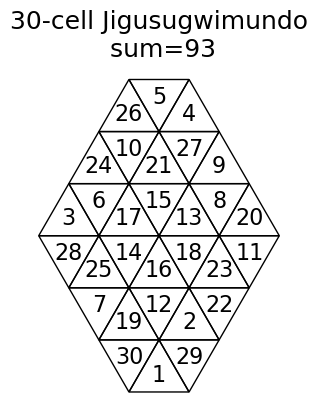

In [12]:
choi=[
    [26, 5, 4],
    [24, 10, 21, 27, 9],
    [3, 6, 17, 15, 13, 8, 20],
    [28, 25, 14, 16, 18, 23, 11],
    [7, 19, 12, 2, 22],
    [30, 1, 29],
]

plot_jigusugwimundo(
    choi,
    sides=(1, 3, 3, 1, 3, 3),
    title="30-cell Jigusugwimundo\n sum=93",
    fontsize=16,
    figsize=(4, 4),
)

In [13]:
choi24 = [
    [10, 15, 22, 14, 11],
    [13, 4, 21, 3, 5, 20, 24],
    [12, 19, 6, 17, 23, 2, 1],
    [18, 7, 8, 9, 16],
]

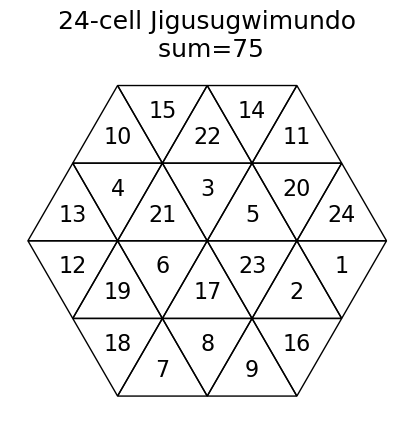

In [14]:
plot_jigusugwimundo(
    choi24,
    sides=(2, 2, 2, 2, 2, 2),
    title="24-cell Jigusugwimundo\n sum=75",
    fontsize=16,
    figsize=(4, 4),
)

In [15]:
empty_hexagram_data(2,1)

[[None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None]]

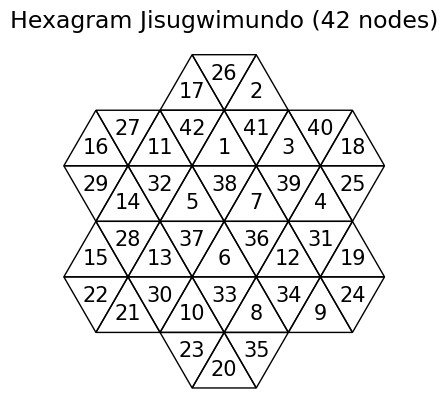

In [16]:
choihexagram = [
    [17, 26, 2],
    [16, 27, 11, 42, 1, 41, 3, 40, 18],
    [29, 14, 32, 5, 38, 7, 39, 4, 25],
    [15, 28, 13, 37, 6, 36, 12, 31, 19],
    [22, 21, 30, 10, 33, 8, 34, 9, 24],
    [23, 20, 35],
]
plot_hexagram(
    choihexagram,
    n=2,
    cut=1,
    title="Hexagram Jisugwimundo (42 nodes)",
    fontsize=15,
    figsize=(4, 4),
)

# A375416-like magic hexagons and hexagrams with subtriangle constraints

For convenience, we refer to the conventional magic hexagon as the S-type (standard type), the previously studied magic T-hexagon as the T-type, and the present construction as the P-type(patch-magic hexagon).

# Magic P-hexagon

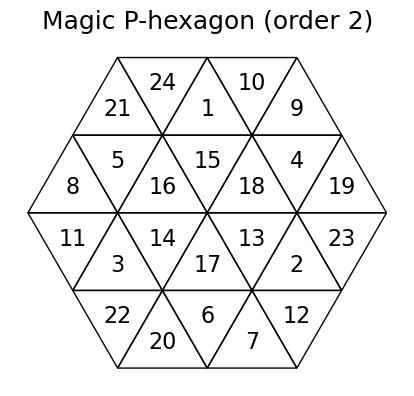

In [20]:
magicPorder2 = [
    [21, 24, 1, 10, 9],
    [8, 5, 16, 15, 18, 4, 19],
    [11, 3, 14, 17, 13, 2, 23],
    [22, 20, 6, 7, 12],
]
plot_jigusugwimundo(
    magicPorder2,
    sides=(2, 2, 2, 2, 2, 2),
    title="Magic P-hexagon (order 2)",
    fontsize=16,
    figsize=(4, 4),
)

# Magic P-hexagram

In [22]:
import itertools
import numpy as np
from scipy import stats
import time

In [23]:
#        0
#    1   2   3
#      4   5
#      6   7
#    8   9   10
#        11
        

In [24]:
i=0
sums=np.zeros([50],dtype=int)
a= time.time()
for star in itertools.permutations(range(1,13), 12):
    if star[2]==max(star[2],star[4],star[5],star[6],star[7],star[9]) and star[4]>star[5]:
        sum1=star[0]+star[2]+star[4]+star[5]
        if sum1==star[2]+star[3]+star[5]+star[7]:
            if sum1==star[5]+star[7]+star[9]+star[10]:
                if sum1==star[6]+star[7]+star[9]+star[11]:
                    if sum1==star[4]+star[6]+star[8]+star[9]:
                        if sum1==star[1]+star[2]+star[4]+star[6]:
                            i+=1
                            print(i,":",star,sum1)
                            sums[sum1]+=1
b=time.time()
print(b-a)
print(sums)

1 : (1, 2, 10, 4, 8, 7, 6, 5, 9, 3, 11, 12) 26
2 : (1, 2, 12, 3, 11, 8, 7, 9, 4, 10, 5, 6) 32
3 : (1, 2, 12, 4, 10, 9, 8, 7, 3, 11, 5, 6) 32
4 : (1, 2, 12, 5, 11, 4, 3, 7, 6, 8, 9, 10) 28
5 : (1, 2, 12, 7, 10, 6, 5, 4, 3, 11, 8, 9) 29
6 : (1, 3, 12, 2, 8, 6, 4, 7, 10, 5, 9, 11) 27
7 : (1, 3, 12, 5, 10, 4, 2, 6, 7, 8, 9, 11) 27
8 : (1, 3, 12, 5, 11, 4, 2, 7, 6, 9, 8, 10) 28
9 : (1, 3, 12, 7, 8, 6, 4, 2, 5, 10, 9, 11) 27
10 : (1, 4, 12, 2, 11, 6, 3, 10, 7, 9, 5, 8) 30
11 : (1, 5, 12, 2, 10, 8, 4, 9, 6, 11, 3, 7) 31
12 : (2, 1, 12, 3, 8, 5, 6, 7, 9, 4, 11, 10) 27
13 : (2, 1, 12, 3, 11, 4, 5, 10, 7, 6, 9, 8) 29
14 : (2, 1, 12, 3, 11, 7, 8, 10, 4, 9, 6, 5) 32
15 : (2, 1, 12, 4, 11, 7, 8, 9, 3, 10, 6, 5) 32
16 : (2, 1, 12, 5, 11, 3, 4, 8, 6, 7, 10, 9) 28
17 : (2, 1, 12, 6, 11, 3, 4, 7, 5, 8, 10, 9) 28
18 : (2, 1, 12, 7, 11, 4, 5, 6, 3, 10, 9, 8) 29
19 : (2, 3, 12, 1, 7, 6, 5, 8, 11, 4, 9, 10) 27
20 : (2, 3, 12, 1, 10, 5, 4, 11, 9, 6, 7, 8) 29
21 : (2, 3, 12, 1, 10, 8, 7, 11, 6, 9, 4, 5) 32
2

In [25]:
#        0
#    1   2   3
#      4   5
#      6   7
#    8   9   10
#        11
        

In [26]:
hexagram1 = [[1], [4, 11, 12, 6, 2], [7, 3, 9, 10, 5], [8]]

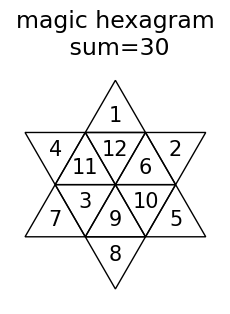

In [27]:
plot_hexagram(
    hexagram1,
    n=1,
    cut=0,
    title="magic hexagram\n sum=30",
    fontsize=15,
    figsize=(3, 3),
)

In [28]:
hexagram2 = [
    [37],
    [17, 6, 38],
    [25, 12, 13, 45, 33, 3, 39, 18, 21, 35, 11],
    [48, 2, 7, 44, 23, 28, 20, 32, 31],
    [26, 41, 29, 24, 1, 27, 42, 15, 9],
    [40, 10, 22, 4, 43, 46, 8, 14, 34, 19, 36],
    [5, 16, 30],
    [47],
]

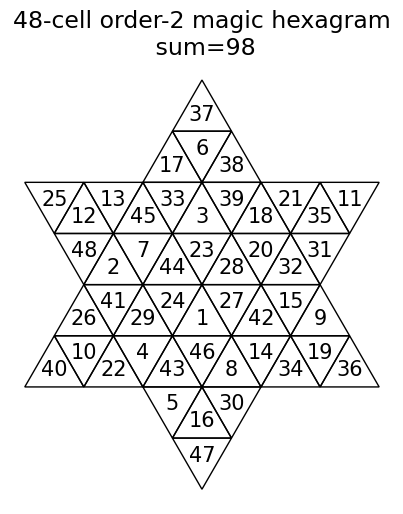

In [29]:
plot_hexagram(
    hexagram2,
    n=2,
    cut=0,
    title="48-cell order-2 magic hexagram\n sum=98",
    fontsize=15,
    figsize=(5, 5),
)

# Magic T-hexagon

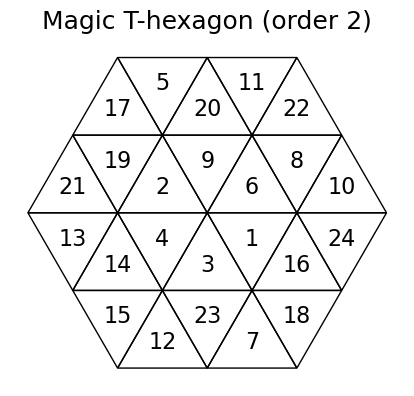

In [31]:
magicTorder2 = [
    [17, 5, 20, 11, 22],
    [21, 19, 2, 9, 6, 8, 10],
    [13, 14, 4, 3, 1, 16, 24],
    [15, 12, 23, 7, 18],
]
plot_jigusugwimundo(
    magicTorder2,
    sides=(2, 2, 2, 2, 2, 2),
    title="Magic T-hexagon (order 2)",
    fontsize=16,
    figsize=(4, 4),
)

# 12-cell row magic hexagram 

In [33]:
hexagram1a = [[12],[11, 1, 4, 7, 9],[5, 10, 8, 6, 3],[2]]
hexagram1b = [[1],[2,12,9,6,4],[8,3,5,7,10],[11]]

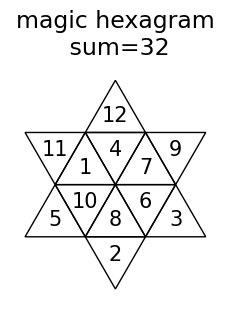

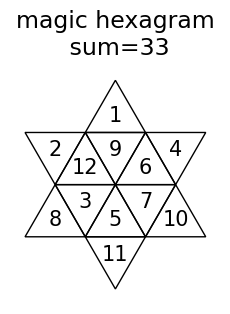

In [34]:
plot_hexagram(
    hexagram1a,
    n=1,
    cut=0,
    title="magic hexagram\n sum=32",
    fontsize=15,
    figsize=(3, 3),
)
plot_hexagram(
    hexagram1b,
    n=1,
    cut=0,
    title="magic hexagram\n sum=33",
    fontsize=15,
    figsize=(3, 3),
)